[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MaxMitre/Mate_MercadosFinancieros/blob/main/Semana13_VaR_y_MonteCarlo.ipynb)

# Estimar riesgo financiero utilizando Monte-Carlo

Entender el análisis de riesgo
Comprender las simulación de Monte Carlo
Aplicar Monte Carlo para predicción de riesgo

# Método de Monte Carlo

Resumido, cuando tenemos incertidumbre de las entradas de nuestro modelo, lo mejor es encontrar distribuciones de probabilidad que nos ayuden a simular el comportamiento de estos datos de entrada

## Ejemplo Ilustrativo

Imagina que eres el jefe de marketing de una firma, que intenta introducir un nuevo producto. Necesitas estimar la ganancia neta del primer año de este producto, que puede depender de:

- Volumen vendido en unidades
- Precio por unidad (llamado precio de venta)
- Costos unitarios
- Costos Fijos

donde

$$ GananciaNeta = VolumenVentas * (PrecioUnitario - CostoUnitario) - CostosFijos$$

Veamos como son los componentes variables de esta modelación.

Por ultimo, se sabe que los **costos fijos** de la empresa son de **$120,000**

## Precio Unitario y Volumen de ventas

Supongamos que hicimos una investigación y obtuvimos que, practicamente, hay 3 estados del mercado que ocurren con la misma probabilidad:

- En un mercado "lento", esperamos vender 50,000 unidades a un precio promedio de $11.00 por unidad

- En un mercado "normal", esperamos vender 75,000 unidades a precio de $10.00 por unidad

- En un mercado "hot", esperamos vender 100,000 unidades, pero como habrá mas competencia el precio baja a $8.00 por unidad

In [ ]:
# Veamos el precio promedio por unidad y el volumen de ventas promedio
import numpy as np
import pandas as pd
units = np.array([50000, 75000, 100000])
prices = np.array([11.0, 10.0, 8.0])
average_unit =  units.mean()
average_price = prices.mean()
print("Promedio de ventas: %.0f" %(average_unit))
print("Precio Promedio: %.2f" %(average_price))

Promedio de ventas: 75000
Precio Promedio: 9.67


## Costo Unitario

Con otro estudio, tu equipo te informó que el costo unitario esta entre 5.5 y 7.5, con un costo promedio de 6.5

## ¿Que pasa si usamos promedio para calcular nuestra ganancia?

In [ ]:
def calNetProfit(average_unit, average_price, average_unitcost, fixed_cost):
    return average_unit*(average_price-average_unitcost)-fixed_cost

average_unitcost = 6.50
fixed_cost = 120000
net_profit = calNetProfit(average_unit,average_price,average_unitcost,fixed_cost)
print("Ganancia Neta: $%.0f" %(net_profit))

Ganancia Neta: $117500




Una frase del Dr. Sam Savage dice, "Plans based on average assumptions will be wrong on average." El resultado calculado está lejos del real, que como veremos mas adelante es $93,000 (lo veremos mas adelante).

In [ ]:
true_net_profit = 93000
error = (net_profit - true_net_profit) / true_net_profit
print("Error relativo: %.3f%%" %(error * 100))

Error relativo: 26.344%


# Monte Carlo para mejorar la estimación

Ahora, asumamos (supuestos a-priori) que el estado del mercado sigue una distribución uniforme discreta y que el costo unitario tiene una distribución uniforme en el intervalo visto. Con esto, tomaremos los valores de volumen y precio de venta como la salida de una variable aleatoria del escenario.

Nótese que en este ejemplo, generamos las variables aleatorias como independientes, lo cual sentido, pero en trabajos mas complejos pueden considerarse las interrelaciones de variables aleatorias para ser mas precisos.

In [ ]:
# Función para obtener volument de ventas y precio basado en el estado del mercado
def get_sales_volume_price(scenario):
    # Slow market
    if scenario == 0:
        return (50000,11.0)
    # Normal market
    if scenario == 1:
        return (75000, 10.0)
    # Hot market
    if scenario == 2:
        return (100000, 8.0)

In [ ]:
import random
total = np.array([])
num_simulation = 100000
for i in range(0,num_simulation):
    unit_cost = random.uniform(5.5, 7.5) #the unit costs may vary between $5.50 to $7.50
    market_scenario = random.randint(0, 2) #to get our market scenario 0, 1 or 2
    sales_volume, price = get_sales_volume_price(market_scenario)
    net_profit = calNetProfit(sales_volume, price, unit_cost, fixed_cost)
    total = np.append(total, net_profit)

print("Ganancia Neta Promedio: %.3f$" %total.mean())

#evaluating the error on the Monte Carlo Simulation Approach
errorMCS = (total.mean() - true_net_profit) / true_net_profit
print("Error Relativo: %.3f%%" %(np.abs(errorMCS * 100)))

val = np.zeros(len(total))
err = np.zeros(len(total))
val[0] = total[0]
err[0] = np.abs((total[0]-true_net_profit)/true_net_profit*100)

for i in range(1, len(total)):
    val[i] = (total[i]+val[i-1])
    x = val[i]/(i+1) #evaluating the sum of all profits until this simulation and mean until now
    err[i] = np.abs((x-true_net_profit)/true_net_profit)

Ganancia Neta Promedio: 92415.718$
Error Relativo: 0.628%


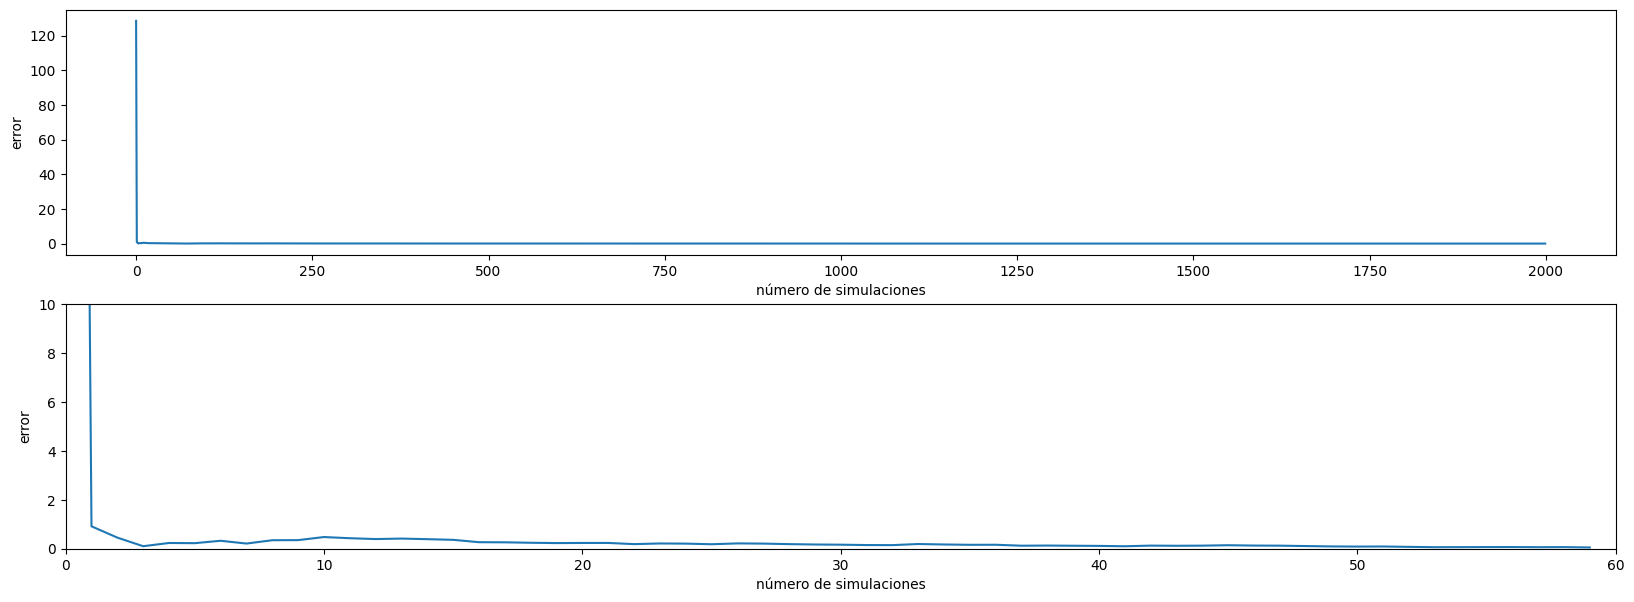

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,7))
plt.subplot(211)
plt.plot(np.arange(2000), err[0:2000])
plt.ylabel("error")
plt.xlabel("número de simulaciones")

plt.subplot(212)
plt.plot(np.arange(60), err[0:60])
plt.ylabel("error")
plt.xlabel("número de simulaciones")
plt.axis([0,60,0,10])
plt.show()

# Distribuciones comunes a utilizar en simulaciones de Monte Carlo

- *Normal/Gaussian Distribución*: Simétrica alrededor de la media, nos dice también que los valores mas cercanos a la media son los mas probables a ocurrir

![normal_distribution](https://upload.wikimedia.org/wikipedia/commons/thumb/7/74/Normal_Distribution_PDF.svg/320px-Normal_Distribution_PDF.svg.png)

- *Distribución Lognormal*: es muy utilizada en precios, pues su rango de valores esta en $[0, \infty]$.

![log_normal_distribution](https://upload.wikimedia.org/wikipedia/commons/thumb/a/ae/PDF-log_normal_distributions.svg/320px-PDF-log_normal_distributions.svg.png)

- *Distribución Triangular*: Utilizada en problemas de inventarios, entre otros.

![](https://upload.wikimedia.org/wikipedia/commons/thumb/4/45/Triangular_distribution_PMF.png/320px-Triangular_distribution_PMF.png)

- *Distribución Uniforme*: Es utilizada en costos de manufactura

![](https://upload.wikimedia.org/wikipedia/commons/thumb/9/96/Uniform_Distribution_PDF_SVG.svg/320px-Uniform_Distribution_PDF_SVG.svg.png)

- *Distribución Exponencial*: Se utiliza para medir el tiempo entre ocurrencias de eventos

![](https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Exponential_pdf.svg/320px-Exponential_pdf.svg.png)

- *Distribución Discreta*: Se utiliza para asignar probabilidades definidas para cada uno de varios eventos.


# Aplicación de lo anterior

In [ ]:
import yfinance as yf

In [ ]:
df = yf.download(  # or pdr.get_data_yahoo(...
        # tickers list or string as well
        tickers = ["^GSPC", "^IXIC", "CL=F", "^TNX", "GOOGL", 'AAPL'],

        # use "period" instead of start/end
        # valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max
        # (optional, default is '1mo')
        period = "5y",

        # fetch data by interval (including intraday if period < 60 days)
        # valid intervals: 1m,2m,5m,15m,30m,60m,90m,1h,1d,5d,1wk,1mo,3mo
        # (optional, default is '1d')
        interval = "1d",

        # group by ticker (to access via data['SPY'])
        # (optional, default is 'column')
        # group_by = 'ticker',
    ).loc[:, 'Adj Close']
df

[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,CL=F,GOOGL,^GSPC,^IXIC,^TNX
Date,,,,,,
2019-10-18 00:00:00+00:00,NaN,53.779999,NaN,NaN,NaN,1.747
2019-10-21 00:00:00+00:00,58.182018,53.310001,62.060326,3006.719971,8162.990234,1.792
2019-10-22 00:00:00+00:00,58.048977,54.160000,61.906712,2995.989990,8104.299805,1.768
2019-10-23 00:00:00+00:00,58.827919,55.970001,62.726181,3004.520020,8119.790039,1.759
2019-10-24 00:00:00+00:00,58.924683,56.230000,62.799999,3010.290039,8185.799805,1.766
...,...,...,...,...,...,...
2024-10-14 00:00:00+00:00,231.300003,73.830002,164.960007,5859.850098,18502.689453,4.098
2024-10-15 00:00:00+00:00,233.850006,70.580002,165.460007,5815.259766,18315.589844,4.038
2024-10-16 00:00:00+00:00,231.779999,70.389999,165.160004,5842.470215,18367.080078,4.016


In [ ]:
df.isna().sum().sum()

4

In [ ]:
df.dropna(inplace=True)

In [ ]:
from datetime import datetime
from datetime import timedelta
from itertools import islice
%matplotlib inline
import numpy as np
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (15,7)

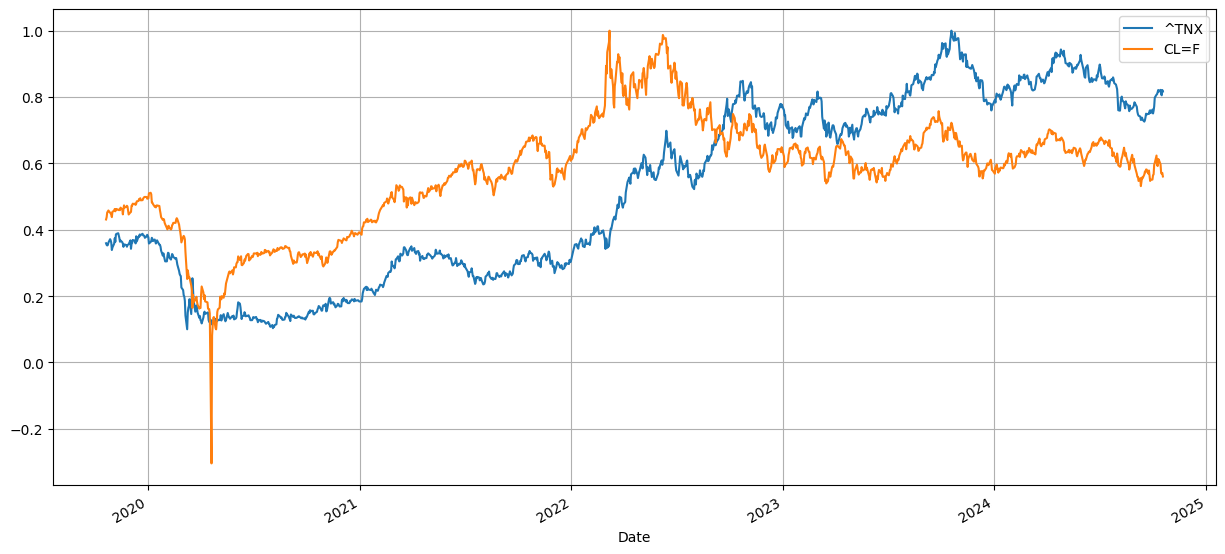

In [ ]:
(df["^TNX"]/df["^TNX"].max()).plot()
(df["CL=F"]/df["CL=F"].max()).plot()
plt.legend()
plt.grid()

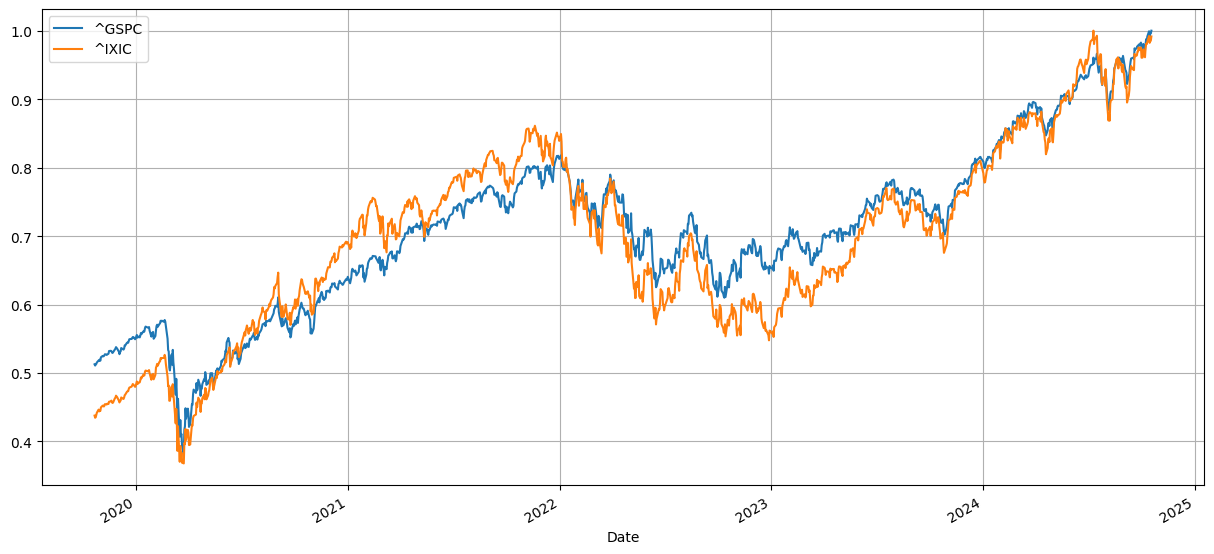

In [ ]:
(df["^GSPC"]/df["^GSPC"].max()).plot()
(df["^IXIC"]/df["^IXIC"].max()).plot()
plt.legend()
plt.grid()

## Retornos cada 15 días (10 días de trading aprox)

In [ ]:
retornos = (df - df.shift(10)) / df.shift(10)
retornos.dropna(inplace=True)
retornos

Ticker,AAPL,CL=F,GOOGL,^GSPC,^IXIC,^TNX
Date,,,,,,
2019-11-04 00:00:00+00:00,0.070642,0.060589,0.036431,0.023797,0.033102,-0.003348
2019-11-05 00:00:00+00:00,0.071553,0.056684,0.040477,0.026245,0.040766,0.055430
2019-11-06 00:00:00+00:00,0.057817,0.006789,0.026542,0.024050,0.035819,0.031268
2019-11-07 00:00:00+00:00,0.068269,0.016361,0.037987,0.024878,0.030384,0.090600
2019-11-08 00:00:00+00:00,0.058160,0.010237,0.035356,0.023335,0.028168,0.073293
...,...,...,...,...,...,...
2024-10-14 00:00:00+00:00,-0.007296,0.083028,-0.005366,0.016897,0.017237,0.077854
2024-10-15 00:00:00+00:00,0.033774,0.010740,-0.009162,0.018657,0.022625,0.078814
2024-10-16 00:00:00+00:00,0.022048,0.004137,-0.004220,0.023282,0.024656,0.061030


<Axes: xlabel='Date'>

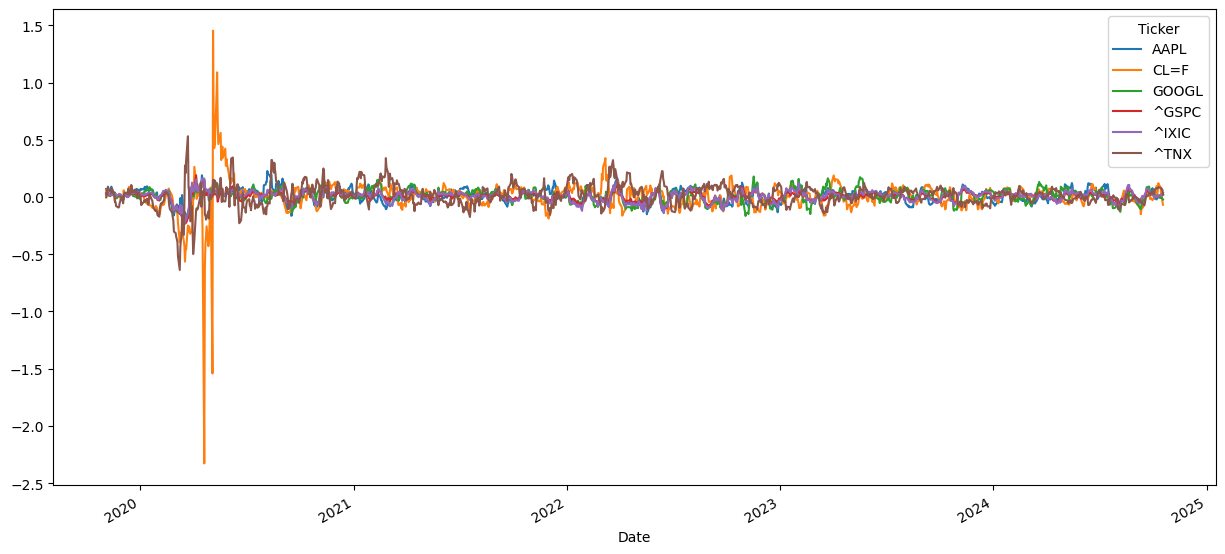

In [ ]:
retornos.plot()

(-0.5, 0.5)

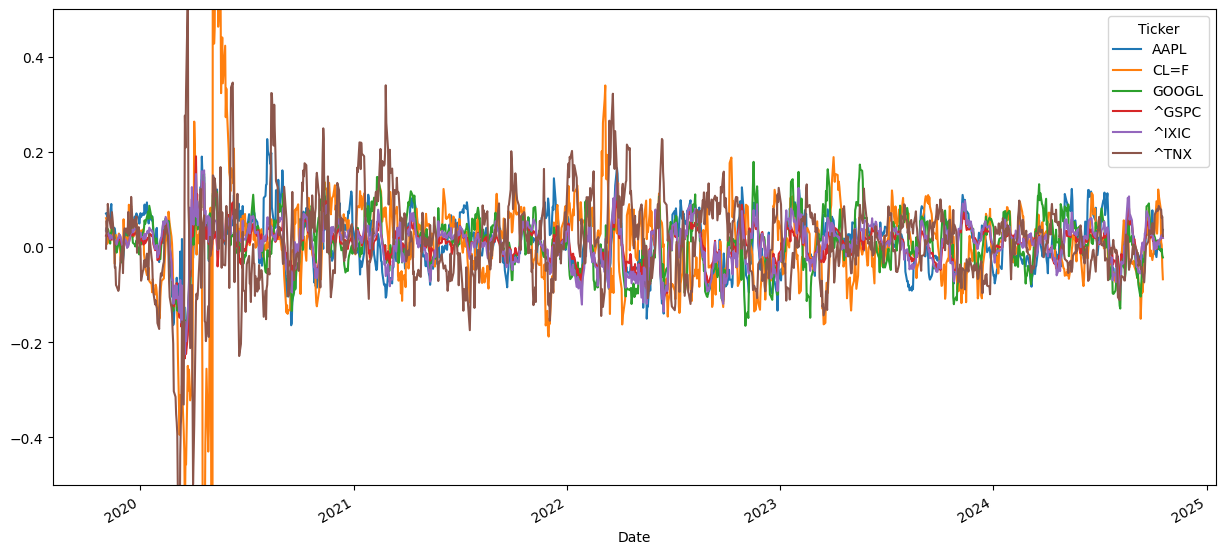

In [ ]:
retornos.plot()
plt.ylim((-0.5, 0.5))

# Pasos para aplicar MC


- **Paso 1**: Definir la relación entre los factores del mercado y los retornos de los instrumentos. Un modelo histórico
- **Paso 2**: Definir las distribuciones de las condiciones del mercado, distribuciones históricas
- **Paso 3**: Generar datos para cada corrida de Monte Carlo
- **Paso 4**: Para cada simulación, utilizando los valores de las condiciones de mercado, y la relación construida en el paso 1, calculamos los retornos de cada instrumento y el retorno total, Utilizamos los retornos para definir una distribución empírica sobre las pérdidas. Esto quiere decir, que si queremos estimar un VaR del 5% en 100 simulaciones, escogeremos las 5 peores.
- **Paso 5**: Evaluar el resultado

## Paso 1:
Sea $v_t$ el vector de los factores de mercado, y $f_t$ la transformación de características de $v_t$ en el tiempo $t$.

$f_{tj}$ es el valor de la característica  $j$ en $f_t$.

Denote $r_{it}$ el retorno del instrumento $i$ en el tiempo $t$ y $c_i$ es el intercepto

Usaremos una función lineal para calcular el retorno:

$$
r_{it} = c_i + \sum_{j=1}^{m}{w_{ij}*f_{tj}}
$$

donde $w_{ij}$ es el parámetro de la característica $j$ para el instrumento $i$.

![](https://dl.dropboxusercontent.com/s/kbjtwmnr4w31uev/process-build-model3.svg)


Pero vamos a utilizar mas carácteristicas del mercado, basadas en los factores dse mercado que tengamos, pero para no solo pensar en una función lineal. ¿Les recuerda esto a algún otro problema?

<div class="alert alert-info">
Tomemos todos los retornos de los factores de mercado $[x_1, x_2,...,x_k]$ y transformemoslos en una nueva lista de características  $[u_1,u_2,..,u_k, v_1, v_2,..,v_k, x_1,x_2,...,x_k]$.

<ul></ul>

Utilizando las siguientes funciones,  


$u_i$ = $\left\{
	\begin{array}{ll}
		x_i^2 & \mbox{if } x_i \geq 0 \\
		-x_i^2 & \mbox{if } x_i < 0
	\end{array}
\right.
$

<ul></ul>

y

$v_i$ = $\left\{
	\begin{array}{ll}
		\sqrt{x_i} & \mbox{if } x_i \geq 0 \\
		-\sqrt{-x_i} & \mbox{if } x_i < 0
	\end{array}
\right.
$  

</div>

In [ ]:
retornos['CL=F_Quad'] = retornos['CL=F'].apply(lambda x: x**2 if x>0 else -x**2)
retornos['CL=F_SQRT'] = retornos['CL=F'].apply(lambda x: np.sqrt(x) if x>0 else -np.sqrt(-x))
retornos['^TNX_Quad'] = retornos['^TNX'].apply(lambda x: x**2 if x>0 else -x**2)
retornos['^TNX_SQRT'] = retornos['^TNX'].apply(lambda x: np.sqrt(x) if x>0 else -np.sqrt(-x))
retornos['^IXIC_Quad'] = retornos['^IXIC'].apply(lambda x: x**2 if x>0 else -x**2)
retornos['^IXIC_SQRT'] = retornos['^IXIC'].apply(lambda x: np.sqrt(x) if x>0 else -np.sqrt(-x))
retornos['^GSPC_Quad'] = retornos['^GSPC'].apply(lambda x: x**2 if x>0 else -x**2)
retornos['^GSPC_SQRT'] = retornos['^GSPC'].apply(lambda x: np.sqrt(x) if x>0 else -np.sqrt(-x))

In [ ]:
retornos

Ticker,AAPL,CL=F,GOOGL,^GSPC,^IXIC,^TNX,CL=F_Quad,CL=F_SQRT,^TNX_Quad,^TNX_SQRT,^IXIC_Quad,^IXIC_SQRT,^GSPC_Quad,^GSPC_SQRT
Date,,,,,,,,,,,,,,
2019-11-04 00:00:00+00:00,0.070642,0.060589,0.036431,0.023797,0.033102,-0.003348,0.003671,0.246148,-0.000011,-0.057864,0.001096,0.181939,0.000566,0.154262
2019-11-05 00:00:00+00:00,0.071553,0.056684,0.040477,0.026245,0.040766,0.055430,0.003213,0.238084,0.003072,0.235436,0.001662,0.201906,0.000689,0.162003
2019-11-06 00:00:00+00:00,0.057817,0.006789,0.026542,0.024050,0.035819,0.031268,0.000046,0.082397,0.000978,0.176827,0.001283,0.189258,0.000578,0.155082
2019-11-07 00:00:00+00:00,0.068269,0.016361,0.037987,0.024878,0.030384,0.090600,0.000268,0.127912,0.008208,0.300999,0.000923,0.174311,0.000619,0.157728
2019-11-08 00:00:00+00:00,0.058160,0.010237,0.035356,0.023335,0.028168,0.073293,0.000105,0.101176,0.005372,0.270726,0.000793,0.167832,0.000545,0.152757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-14 00:00:00+00:00,-0.007296,0.083028,-0.005366,0.016897,0.017237,0.077854,0.006894,0.288145,0.006061,0.279023,0.000297,0.131288,0.000286,0.129989
2024-10-15 00:00:00+00:00,0.033774,0.010740,-0.009162,0.018657,0.022625,0.078814,0.000115,0.103636,0.006212,0.280738,0.000512,0.150418,0.000348,0.136592
2024-10-16 00:00:00+00:00,0.022048,0.004137,-0.004220,0.023282,0.024656,0.061030,0.000017,0.064319,0.003725,0.247043,0.000608,0.157022,0.000542,0.152585


## Regresión

In [ ]:
retornos.columns

Index(['AAPL', 'CL=F', 'GOOGL', '^GSPC', '^IXIC', '^TNX', 'CL=F_Quad',
       'CL=F_SQRT', '^TNX_Quad', '^TNX_SQRT', '^IXIC_Quad', '^IXIC_SQRT',
       '^GSPC_Quad', '^GSPC_SQRT'],
      dtype='object', name='Ticker')

In [ ]:
regresion = sm.OLS(retornos['AAPL'], sm.add_constant(retornos.drop(['AAPL', "GOOGL"], axis=1)))

In [ ]:
entrenado = regresion.fit()

In [ ]:
entrenado.params

,0
const,0.005359
CL=F,0.046341
^GSPC,-0.443855
^IXIC,1.575121
^TNX,-0.006145
CL=F_Quad,-0.010298
CL=F_SQRT,-0.025686
^TNX_Quad,0.026794
^TNX_SQRT,-0.003577
^IXIC_Quad,-3.354720


## Paso 2: Ver las distribuciones de las condiciones de mercado.

<Axes: >

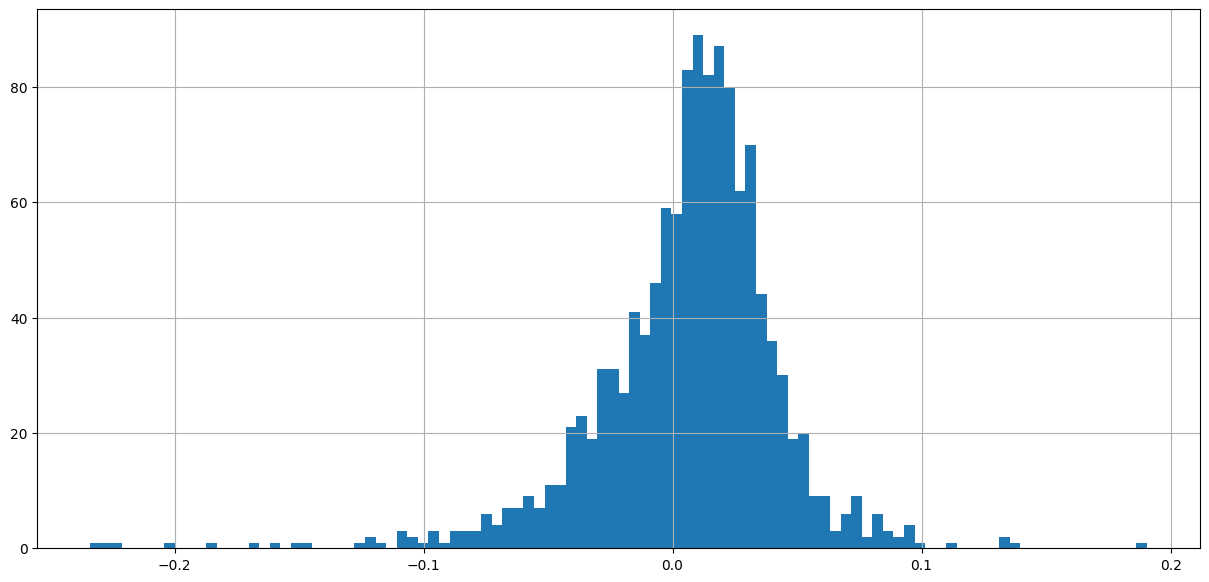

In [ ]:
retornos['^GSPC'].hist(bins=100)

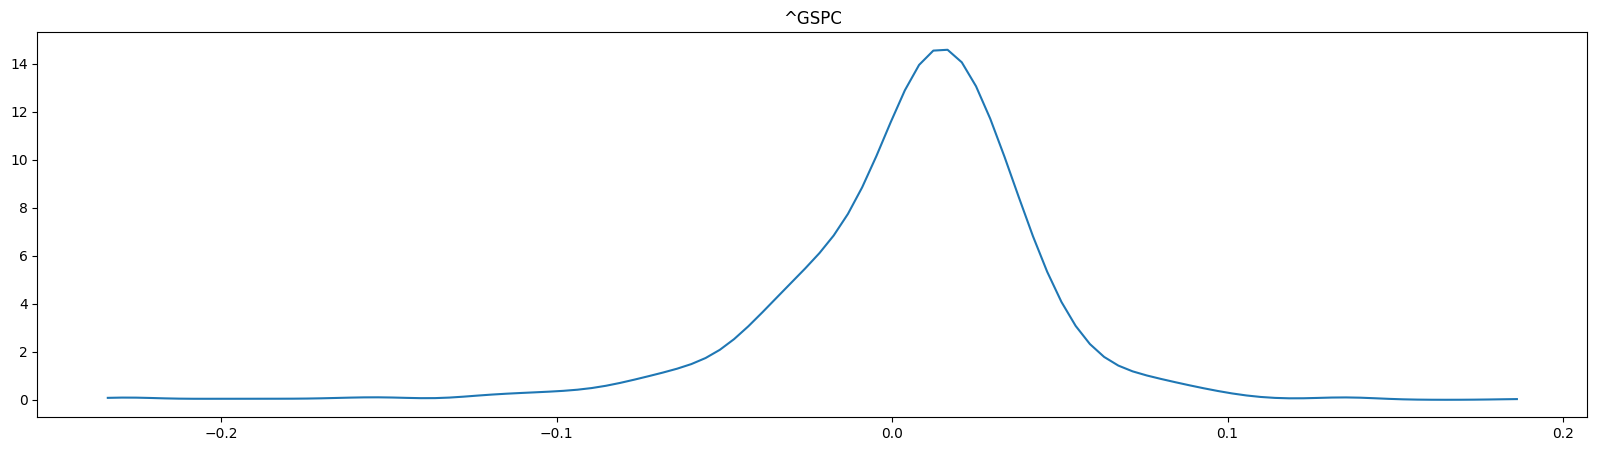

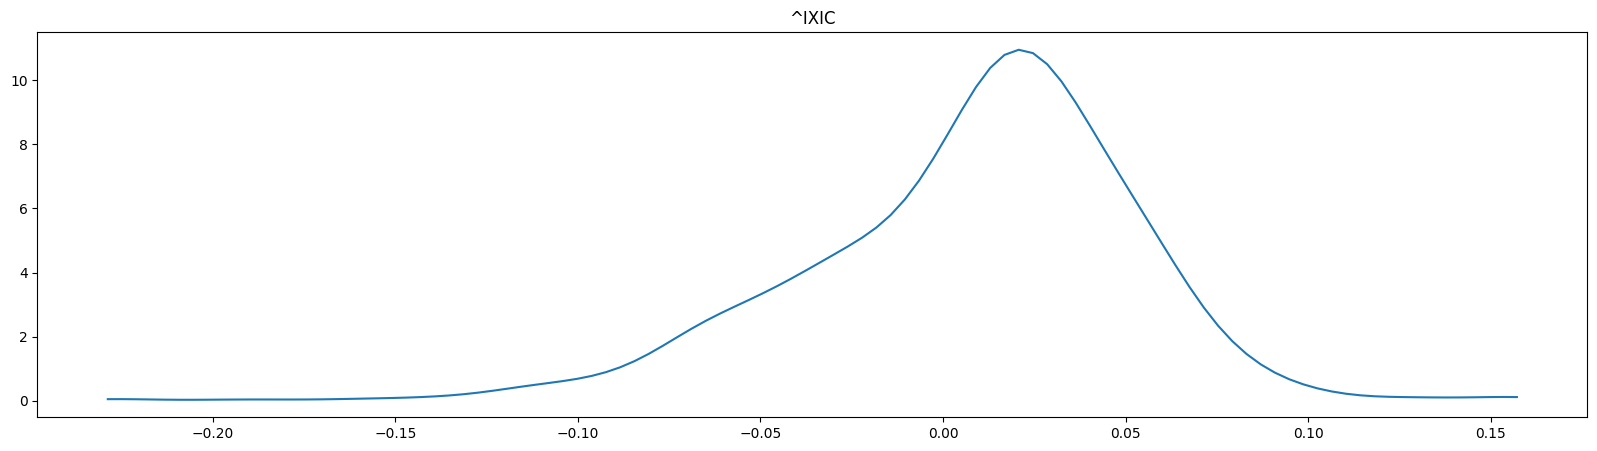

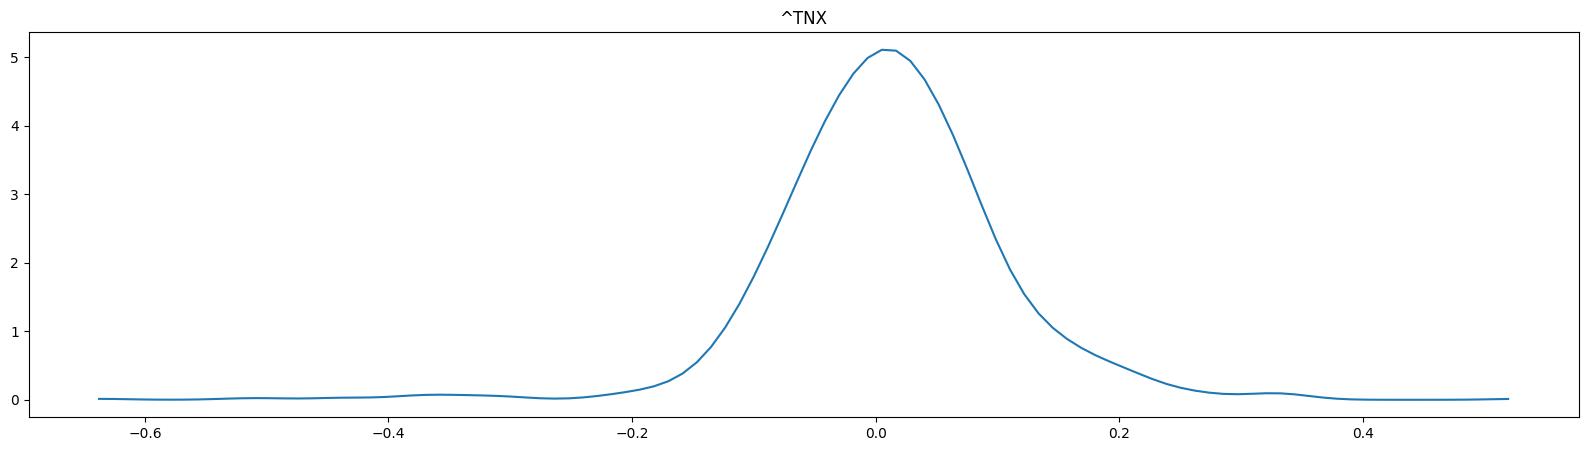

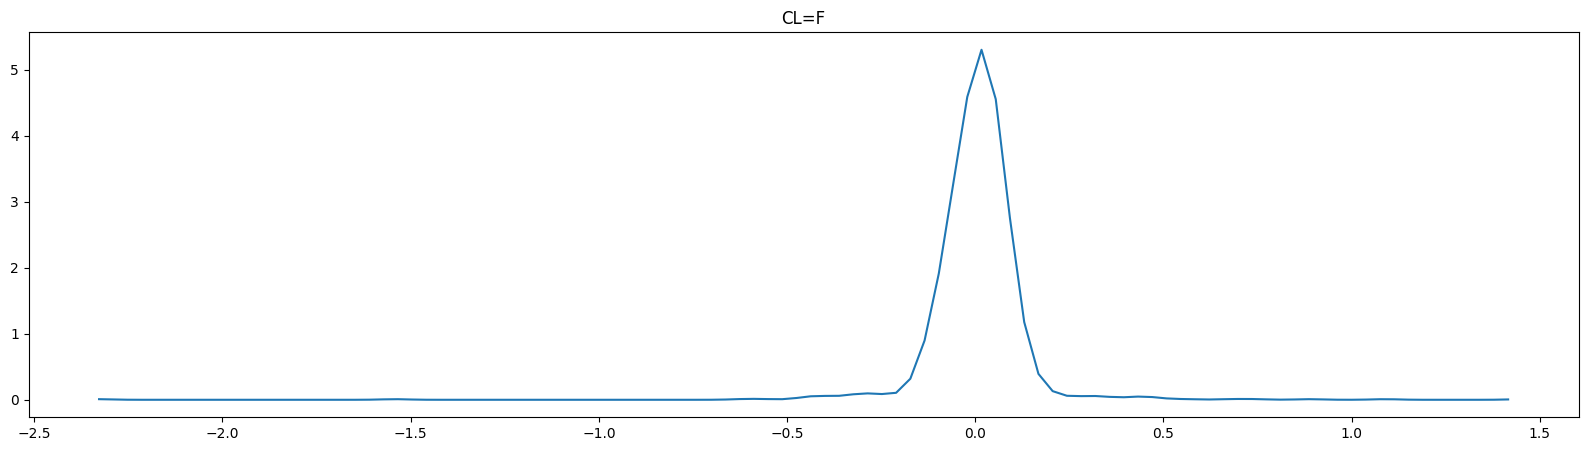

In [ ]:
from statsmodels.nonparametric.kernel_density import KDEMultivariate
from statsmodels.nonparametric.kde import KDEUnivariate
import matplotlib.pyplot as plt
import scipy

def plotDistribution(samples, label = None, plot=True, vmin=None, vmax=None):
    if vmin == None:
        vmin = min(samples)
    if vmax == None:
        vmax = max(samples)

    stddev = np.std(samples)

    domain = np.arange(vmin, vmax, (vmax-vmin)/100)
    #the last value could be greater than vmax, in this case we remove it
    #check np docs https://docs.scipy.org/doc/numpy/reference/generated/numpy.arange.html
    if len(domain)>100:
        domain=np.delete(domain, domain[-1])
    # a simple heuristic to select bandwidth
    bandwidth = 1.06 * stddev * pow(len(samples), -.2)

    # estimate density
    kde = KDEUnivariate(samples)
    kde.fit(bw=bandwidth)
    density = kde.evaluate(domain)
    if len(density)>100:
        density=np.delete(density, domain[-1])
    # plot
    if plot:
        plt.figure(figsize=(20,5))
        if label:
            plt.title(label)
        plt.plot(domain, density)
        plt.show()
    else:
        return domain, density

factors_names = ['^GSPC', '^IXIC', '^TNX', 'CL=F']
for i in range(4):
    plotDistribution(retornos[factors_names[i]], factors_names[i])

Correlaciones

In [ ]:
retornos[factors_names].corr()

Ticker,^GSPC,^IXIC,^TNX,CL=F
Ticker,,,,
^GSPC,1.000000,0.937378,-0.001809,0.163906
^IXIC,0.937378,1.000000,-0.077153,0.119414
^TNX,-0.001809,-0.077153,1.000000,0.198296
CL=F,0.163906,0.119414,0.198296,1.000000


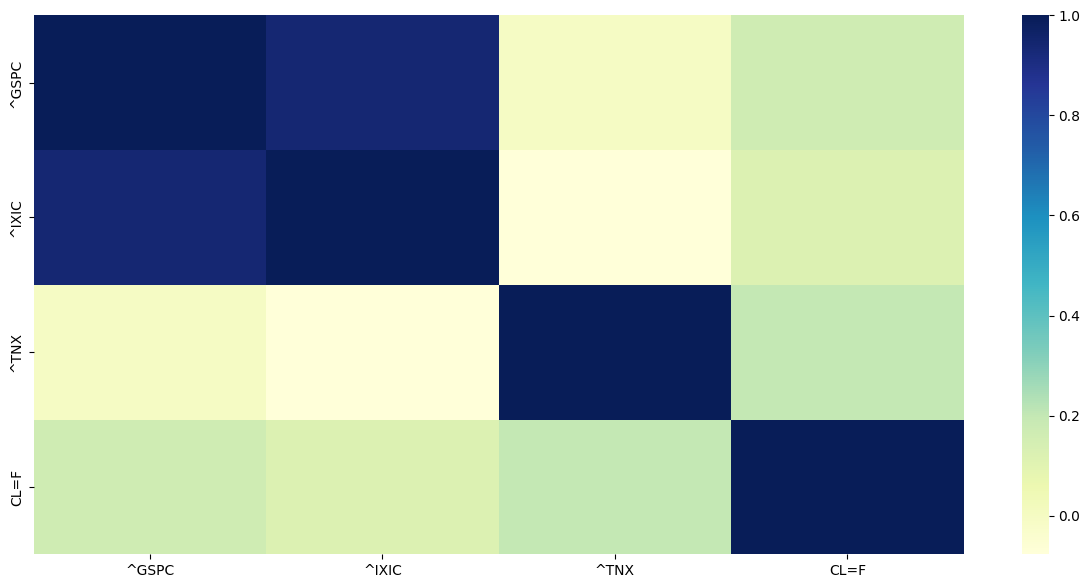

In [ ]:
ax = sns.heatmap(np.array(retornos[factors_names].corr()), cmap="YlGnBu", \
                 xticklabels=factors_names, \
                 yticklabels=factors_names)

Para nuestro caso, podemos tomar:

$$
\left(\begin{array}{c}f_{1}\\f_{2}\\f_{3}\\f_{4} \end{array}\right)
\sim N
\left[
  \left(
    \begin{array}{c}
      \mu_1\\ \mu_2 \\ \mu_3 \\ \mu_4
    \end{array}
  \right),
  \left(
    \begin{array}{cccc}
      \sigma^2_1 & \rho_{12} \sigma_1\sigma_2 & \rho_{13} \sigma_1\sigma_3 & \rho_{14} \sigma_1\sigma_4 \\
      \rho_{12}\sigma_2\sigma_1 & \sigma^2_2 & \rho_{23} \sigma_2\sigma_3 & \rho_{24} \sigma_2\sigma_4\\
      \rho_{13} \sigma_3\sigma_1 & \rho_{23} \sigma_3\sigma_2 & \sigma^2_3 & \rho_{34} \sigma_3\sigma_4 \\
      \rho_{14} \sigma_4\sigma_1 & \rho_{24} \sigma_4\sigma_2 & \rho_{34} \sigma_3\sigma_4 & \sigma_4^2 \\
    \end{array}
  \right)
\right]
$$

o,

$$
f_t \sim N(\mu, \sum)
$$

Donde $f_1$, $f_2$, $f_3$ y $f_4$ son los factores de mercado, $\sigma_i$ es la desviación estandar del factor $i$, $\mu$ es la media empirica de los retornos de los factores y $\sum$ es la matriz de covarianzas empirica.

In [ ]:
factorCov = np.array(retornos[factors_names].cov())
factorMeans = [sum(retornos[x])/len(retornos[x]) for x in factors_names]
sample = np.random.multivariate_normal(factorMeans, factorCov)

print(factorCov)
print(factorMeans)
print(sample)

[[ 1.40847891e-03  1.58875426e-03 -6.41939276e-06  8.49928229e-04]
 [ 1.58875426e-03  2.03954611e-03 -3.29545361e-04  7.45134585e-04]
 [-6.41939276e-06 -3.29545361e-04  8.94524871e-03  2.59132822e-03]
 [ 8.49928229e-04  7.45134585e-04  2.59132822e-03  1.90907599e-02]]
[0.0059591708365892325, 0.00745622036912122, 0.011442277503375653, 0.005338487838377372]
[ 0.0008973  -0.00041519  0.0103686  -0.02134419]


# Diferencias entre empiricas y obtenidas con KDE

In [ ]:
def mse(true_values, estimated_values):
    return sum(np.square(true_values - estimated_values))

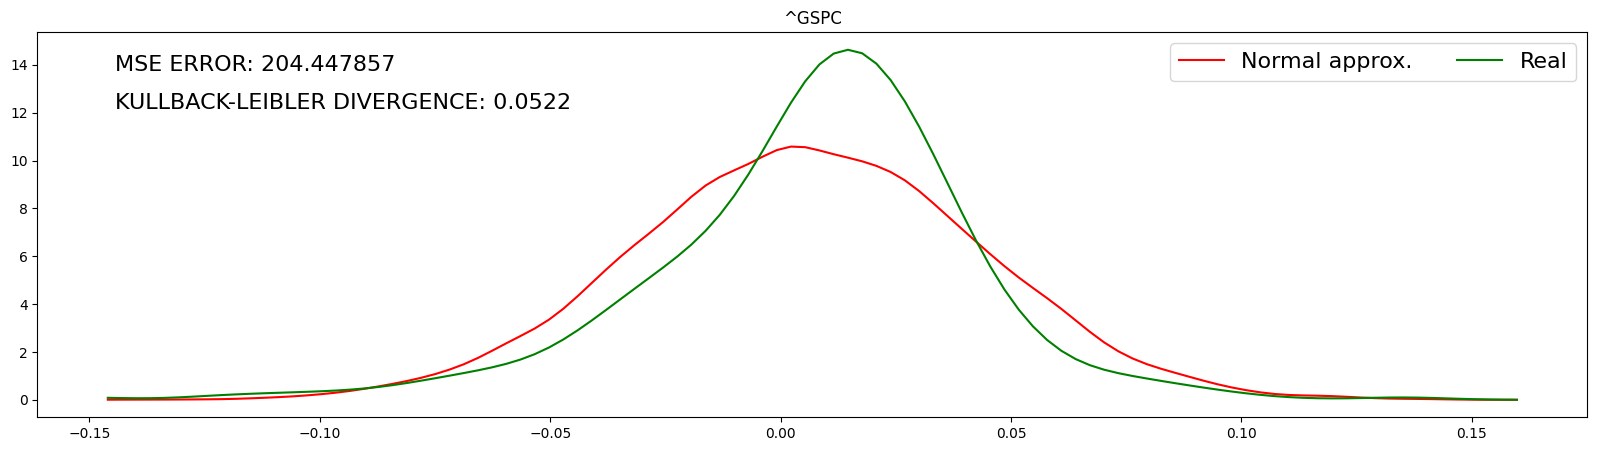

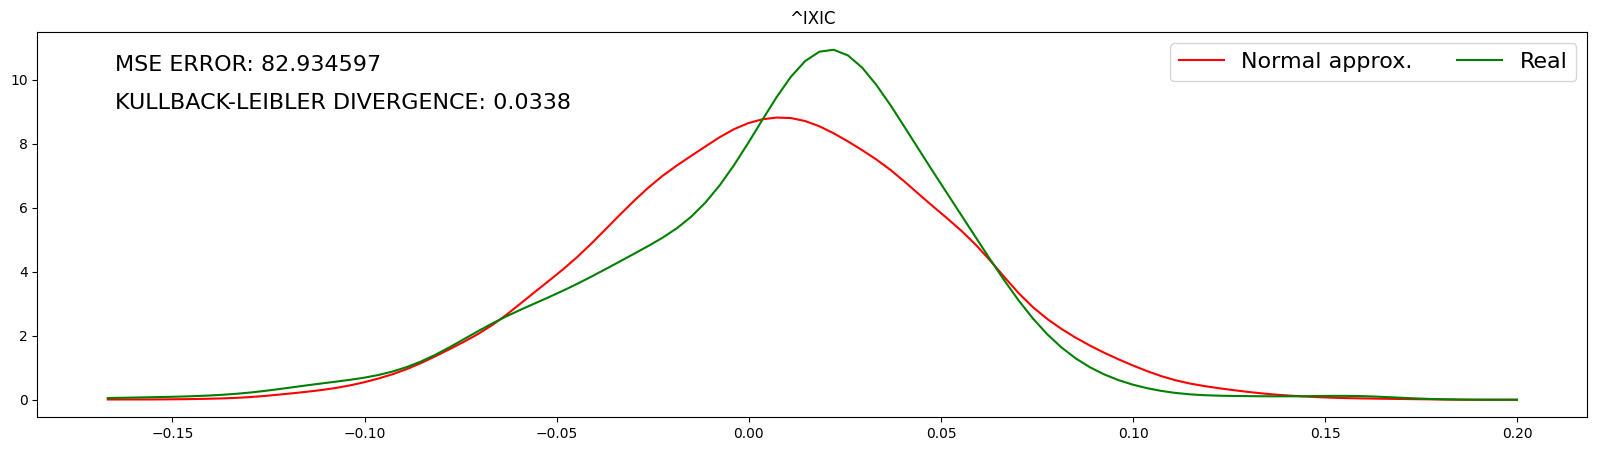

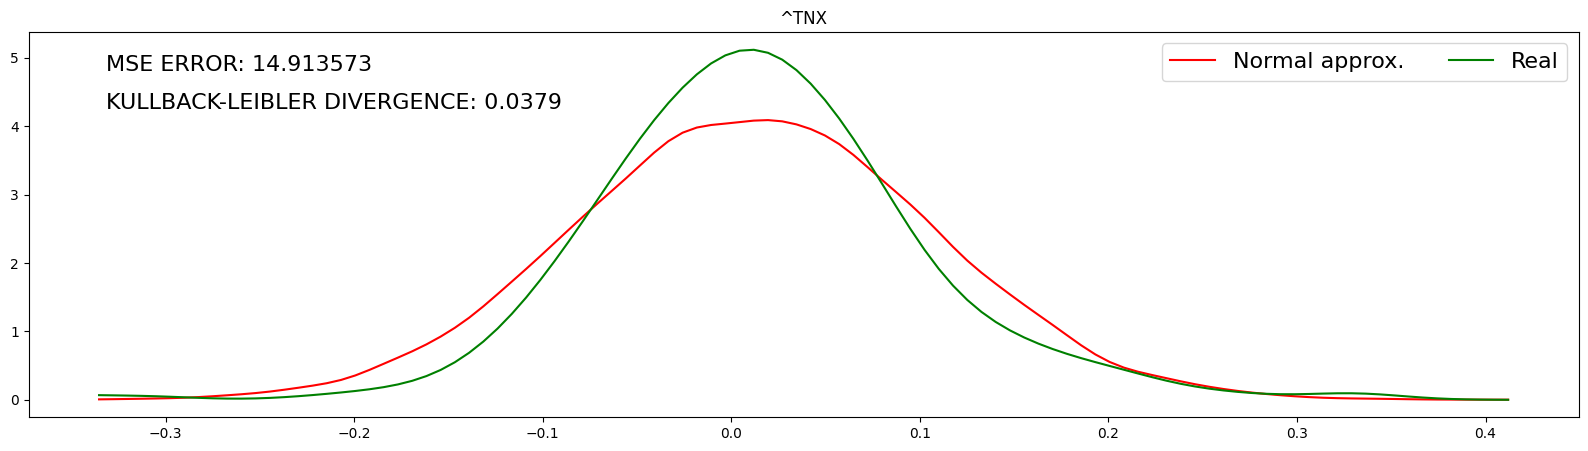

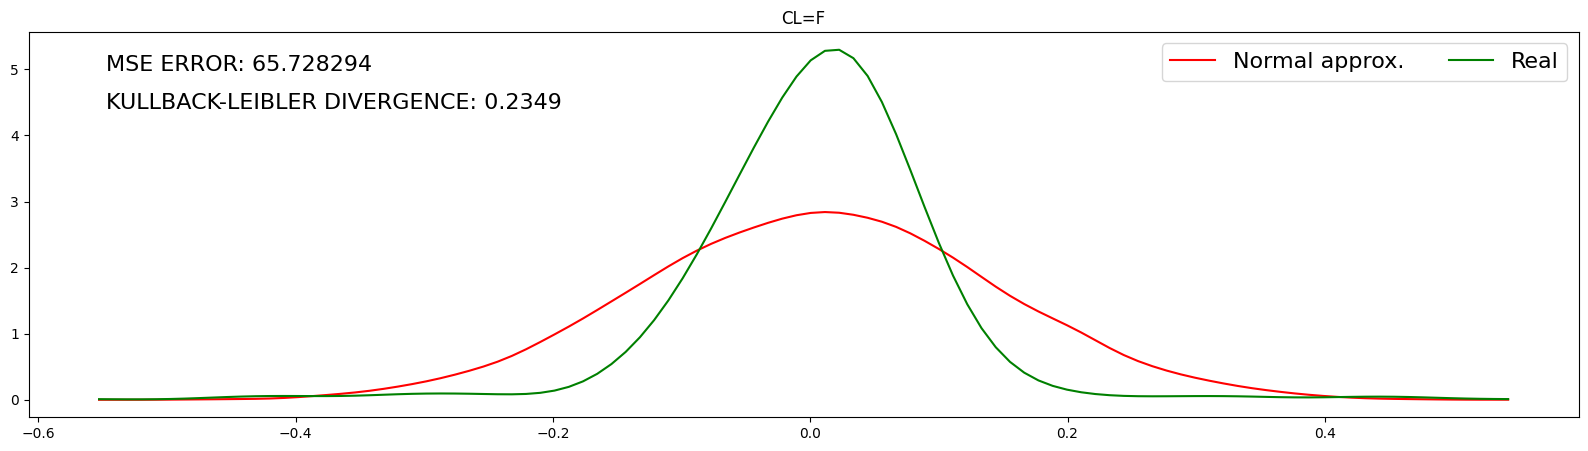

In [ ]:
xx = np.random.multivariate_normal(factorMeans, factorCov, 20000)
xx = xx.transpose()
for f, num in zip(xx, np.arange(4)):
    vmin = min(f)
    vmax = max(f)
    sampledDomain, sampledDensity = plotDistribution(f, plot=False, vmin=vmin, vmax=vmax)
    domain, density = plotDistribution(retornos[factors_names].iloc[:,num], plot=False, vmin=vmin, vmax=vmax)
    err =  mse(density, sampledDensity)
    err2 = scipy.stats.entropy(density, sampledDensity)
    plt.figure(figsize=(20,5))
    ax = plt.gca()
    plt.title(factors_names[num])
    ax.text(0.05, 0.9, 'MSE ERROR: %f'%err, transform = ax.transAxes)
    ax.text(0.05, 0.8, 'KULLBACK-LEIBLER DIVERGENCE: %.4f'%err2, transform = ax.transAxes)
    ax.texts[0].set_fontsize(16)
    ax.texts[1].set_fontsize(16)
    plt.plot(sampledDomain, sampledDensity, color="r", label="Normal approx.")
    plt.plot(domain, density, color="g", label="Real")
    plt.legend(ncol=2, loc='upper right', frameon=True, fontsize=16)
    plt.show()

# Pasos 3 y 4: Generando muestras, obteniendo simulaciones y calculando el VaR

In [ ]:
def fivePercentVaR(trials):
    numTrials = trials.count()
    topLosses = trials.takeOrdered(max(round(numTrials/20.0), 1))
    return topLosses[-1]

# an extension of VaR
def fivePercentCVaR(trials):
    numTrials = trials.count()
    topLosses = trials.takeOrdered(max(round(numTrials/20.0), 1))
    return sum(topLosses)/len(topLosses)

def bootstrappedConfidenceInterval(
      trials, computeStatisticFunction,
      numResamples, pValue):
    stats = []
    for i in range(0, numResamples):
        resample = trials.sample(True, 1.0)
        stats.append(computeStatisticFunction(resample))
    sorted(stats)
    lowerIndex = int(numResamples * pValue / 2 - 1)
    upperIndex = int(np.ceil(numResamples * (1 - pValue / 2)))
    return (stats[lowerIndex], stats[upperIndex])

In [ ]:
from pyspark import SparkContext

# Initialize SparkContext
sc = SparkContext("local", "Parallelize Example")

In [ ]:
entrenado.params

,0
const,0.005359
CL=F,0.046341
^GSPC,-0.443855
^IXIC,1.575121
^TNX,-0.006145
CL=F_Quad,-0.010298
CL=F_SQRT,-0.025686
^TNX_Quad,0.026794
^TNX_SQRT,-0.003577
^IXIC_Quad,-3.354720


In [ ]:
# RUN SILMULATION
def simulateTrialReturns(numTrials, factorMeans, factorCov, weights):
    trialReturns = []
    for i in range(0, numTrials):
        # generate sample of factors' returns
        trialFactorReturns = pd.DataFrame(np.append(np.array(1).reshape(1,-1),np.random.multivariate_normal(factorMeans, factorCov).reshape(1,-1), axis=1), columns = ['const', '^GSPC', '^IXIC', '^TNX', 'CL=F'])
        trialFactorReturns = trialFactorReturns[['const', 'CL=F', '^GSPC', '^IXIC', '^TNX']]
        trialFactorReturns['CL=F_Quad'] = trialFactorReturns['CL=F'].apply(lambda x: x**2 if x>0 else -x**2)
        trialFactorReturns['CL=F_SQRT'] = trialFactorReturns['CL=F'].apply(lambda x: np.sqrt(x) if x>0 else np.sqrt(-x))
        trialFactorReturns['^TNX_Quad'] = trialFactorReturns['^TNX'].apply(lambda x: x**2 if x>0 else -x**2)
        trialFactorReturns['^TNX_SQRT'] = trialFactorReturns['^TNX'].apply(lambda x: np.sqrt(x) if x>0 else np.sqrt(-x))
        trialFactorReturns['^IXIC_Quad'] = trialFactorReturns['^IXIC'].apply(lambda x: x**2 if x>0 else -x**2)
        trialFactorReturns['^IXIC_SQRT'] = trialFactorReturns['^IXIC'].apply(lambda x: np.sqrt(x) if x>0 else np.sqrt(-x))
        trialFactorReturns['^GSPC_Quad'] = trialFactorReturns['^GSPC'].apply(lambda x: x**2 if x>0 else -x**2)
        trialFactorReturns['^GSPC_SQRT'] = trialFactorReturns['^GSPC'].apply(lambda x: np.sqrt(x) if x>0 else np.sqrt(-x))

        trialFeatures = trialFactorReturns.values.reshape(-1,)

        trialTotalReturn = 0


        # calculate the return of each instrument
        # then calulate the total of return for this trial features
        weights = np.array(weights).reshape(-1,)
        instrumentReturn = np.dot(weights, trialFeatures)
        trialTotalReturn += instrumentReturn

        trialReturns.append(trialTotalReturn)
    return trialReturns



parallelism = 12
numTrials = 10000
trial_indexes = list(range(0, parallelism))
seedRDD = sc.parallelize(trial_indexes, parallelism)
bFactorWeights = sc.broadcast(list(entrenado.params.values))

trials = seedRDD.flatMap(lambda idx: \
                         simulateTrialReturns(max(int(numTrials/parallelism), 1), \
                                              factorMeans, factorCov, bFactorWeights.value))
trials.cache()

valueAtRisk = fivePercentVaR(trials)
conditionalValueAtRisk = fivePercentCVaR(trials)

print ("Value at Risk(VaR) 5%:", valueAtRisk)
print ("Conditional Value at Risk(CVaR) 5%:", conditionalValueAtRisk)

Value at Risk(VaR) 5%: -0.08296684067875029
Conditional Value at Risk(CVaR) 5%: -0.10083187148468808


In [ ]:
retornos.AAPL.quantile(0.05)

-0.08264932823495649

In [ ]:
retornos['AAPL'][retornos['AAPL']<retornos.AAPL.quantile(0.05)].mean()

-0.11051219369895457


# Referencias

Capítulo 9 del libro [Advanced Analytics with Spark de Josh Wills, Sandy Riza, Sean Owen y Uri Laserson](https://www.oreilly.com/library/view/advanced-analytics-with/9781491912751/)

[Github](https://github.com/alegaballo/AML/blob/master/%5BLecture%207%2B8%5D%20Estimating%20Financial%20Risk%20through%20Monte%20Carlo%20Simulation.ipynb)

